# Maksimum Kesim Problemi

# Max-Cut Problemi: Tanım

## Problem Nedir?

**Max-Cut (Maksimum Kesit)** problemi, çizge kuramında yer alan klasik bir optimizasyon problemidir.

Elimizde bir çizge olduğunu düşünelim:

**G = (V, E)**

Burada:

- **V**: düğüm (vertex) kümesi
- **E**: kenar (edge) kümesi

Amaç, düğümleri iki ayrı kümeye ayırmaktır. Bu ayırma sonucunda, bir ucu bir kümede diğer ucu öteki kümede kalan kenarların sayısı ya da toplam ağırlığı **maksimum** olacak şekilde bir bölme elde etmek isteriz.

Bu iki küme genellikle şu şekilde gösterilir:

- **S**
- **V \\ S**

---

## Sezgisel Açıklama

Bir çizgedeki düğümleri iki gruba ayırdığımızda bazı kenarlar aynı grup içinde kalır, bazıları ise iki farklı grup arasında kalır.

**Max-Cut problemi**, iki grup arasında kalan kenarların sayısını veya toplam ağırlığını mümkün olduğunca büyütmeyi amaçlar.

Yani hedef şudur:

- düğümleri iki parçaya ayırmak,
- bu iki parça arasındaki bağlantıyı en büyük yapmak.

---

## Matematiksel Tanım

Bir kesit (cut), **S ⊆ V** olmak üzere şu şekilde tanımlanır:

$$
\delta(S) = \{(u,v) \in E \mid u \in S,\; v \in V \setminus S \}
$$

Burada **δ(S)**, farklı kümelere düşen düğümler arasındaki kenarları ifade eder.

Amaç, aşağıdaki değeri maksimize etmektir:

$$
\max |\delta(S)|
$$

Eğer çizge ağırlıklı ise, bu durumda amaç kenar sayısını değil, kesiti oluşturan kenarların toplam ağırlığını maksimize etmektir:

$$
\max \sum_{(u,v)\in \delta(S)} w_{uv}
$$

Burada **w_uv**, ilgili kenarın ağırlığını gösterir.

---

## Neden Önemlidir?

Max-Cut problemi şu alanlarda önemli bir yere sahiptir:

- kombinatoryal optimizasyon
- çizge teorisi
- yöneylem araştırması
- kuantum optimizasyon

Ayrıca bu problem, klasik yöntemlerin yanında **QAOA (Quantum Approximate Optimization Algorithm)** gibi kuantum algoritmalarının test edilmesinde en sık kullanılan örnek problemlerden biridir.

---

## Notebook İçin Not

Bu notebook boyunca:

1. Max-Cut probleminin matematiksel yapısını inceleyeceğiz.
2. Problemi bir çizge üzerinde görselleştireceğiz.
3. Klasik ve kuantum bakış açılarıyla ele alacağız.
4. Qiskit kullanarak çözüme uygun formülasyonunu kuracağız.

> Bu ilk bölümde yalnızca problemin temel tanımı verilmiştir.  
> İlerleyen adımlarda:
> 1. küçük boyutlu bir TSP örneği tanımlayacağız,
> 2. aday rotaları nasıl kodlayacağımızı göstereceğiz,
> 3. geçerli turları ve maliyet koşulunu belirleyen oracle mantığını kuracağız,
> 4. son olarak Grover Search ile bu problem arasında nasıl bir bağlantı kurulduğunu inceleyeceğiz.

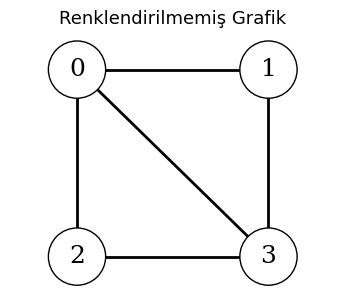

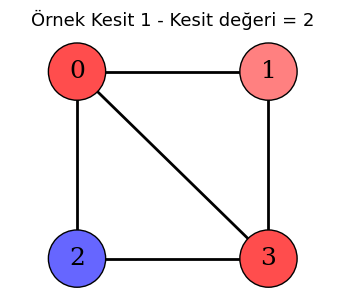

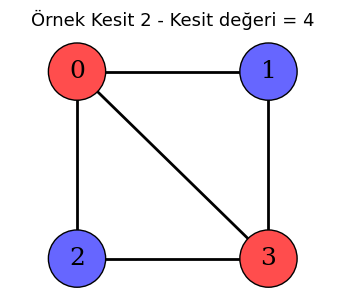

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

# Grafik tanımı
G = nx.Graph()
edges = [(0, 1), (0, 2), (2, 3), (1, 3), (0, 3)]
G.add_edges_from(edges)

# Görsellerdeki kare düzen
pos = {
    0: (0, 1),  # sol üst
    1: (1, 1),  # sağ üst
    2: (0, 0),  # sol alt
    3: (1, 0)   # sağ alt
}

def count_cut_edges(graph, partition):
    return sum(1 for u, v in graph.edges() if partition[u] != partition[v])

def draw_graph(graph, pos, node_colors, title=None):
    plt.figure(figsize=(4.2, 3.4))
    
    nx.draw_networkx_edges(
        graph,
        pos,
        width=2,
        edge_color="black"
    )
    
    nx.draw_networkx_nodes(
        graph,
        pos,
        node_color=node_colors,
        node_size=1700,
        edgecolors="black",
        linewidths=1.0
    )
    
    nx.draw_networkx_labels(
        graph,
        pos,
        font_size=18,
        font_color="black",
        font_family="serif"
    )
    
    if title:
        plt.title(title, fontsize=13)
    
    plt.xlim(-0.35, 1.35)
    plt.ylim(-0.2, 1.2)
    plt.axis("off")
    plt.show()

# 1) Renksiz grafik
colors_plain = ["white", "white", "white", "white"]
draw_graph(G, pos, colors_plain, title="Renklendirilmemiş Grafik")

# 2) İki kenarlı örnek
# 0,1,3 kırmızı; 2 mavi
partition_2edge = {0: 1, 1: 1, 2: 0, 3: 1}
colors_2edge = ["#ff4d4d", "#ff8080", "#6666ff", "#ff4d4d"]
draw_graph(
    G,
    pos,
    colors_2edge,
    title=f"Örnek Kesit 1 - Kesit değeri = {count_cut_edges(G, partition_2edge)}"
)

# 3) Dört kenarlı maksimum kesit
# 0,3 kırmızı; 1,2 mavi
partition_maxcut = {0: 1, 1: 0, 2: 0, 3: 1}
colors_maxcut = ["#ff4d4d", "#6666ff", "#6666ff", "#ff4d4d"]
draw_graph(
    G,
    pos,
    colors_maxcut,
    title=f"Örnek Kesit 2 - Kesit değeri = {count_cut_edges(G, partition_maxcut)}"
)

## Örnek Grafik ve Kesitler

Aşağıda dört düğüm ve beş kenardan oluşan bir grafik gösterilmektedir.

İlk görselde grafik henüz renklendirilmemiştir.  
Sonraki iki görselde ise düğümler iki farklı kümeyi temsil edecek şekilde kırmızı ve mavi renklere boyanmıştır.

Max-Cut probleminde amaç, **farklı kümelerde bulunan düğümleri birbirine bağlayan kenarların sayısını en büyük yapmaktır**.

Bu örnekte:

- İlk renklendirmede kesit değeri **2**'dir.
- İkinci renklendirmede kesit değeri **4**'tür.

Dört düğümlü bu grafik için elde edilebilecek en büyük değer **4** olduğundan, ikinci renklendirme bir **maksimum kesit** örneğidir.

> Burada aynı renkteki düğümler aynı kümeye, farklı renkteki düğümler ise farklı kümelere aittir.

# Max-Cut Probleminin Matematiksel Yapısı

## İkili Değişkenlerle Gösterim

Max-Cut problemi, her düğümün iki farklı kümeden birine atanması şeklinde ifade edilebilir.  
Bu amaçla her düğüm için bir ikili değişken tanımlarız:

$$
x_i \in \{0, 1\}
$$

Burada:

- \( x_i = 0 \) → düğüm birinci kümede
- \( x_i = 1 \) → düğüm ikinci kümede

---

## Kenar Katkısı (Edge Contribution)

Bir kenarın kesite katkı yapabilmesi için uçlarının farklı kümelerde olması gerekir.

İki düğüm için aşağıdaki durum geçerlidir:

$$
x_i \neq x_j \Rightarrow \text{kenar kesite katkı sağlar}
$$

$$
x_i = x_j \Rightarrow \text{katkı sağlamaz}
$$

Bu durumu matematiksel olarak şu şekilde ifade edebiliriz:

$$
x_i \oplus x_j
$$

Ancak optimizasyon problemleri için daha uygun bir form:

$$
x_i + x_j - 2 x_i x_j
$$

Bu ifade:

- 1 verir → farklı kümeler
- 0 verir → aynı küme

---

## Amaç Fonksiyonu

Tüm kenarlar üzerinden toplam katkıyı toplarsak:

$$
\max \sum_{(i,j) \in E} (x_i + x_j - 2 x_i x_j)
$$

Eğer çizge ağırlıklı ise:

$$
\max \sum_{(i,j) \in E} w_{ij} (x_i + x_j - 2 x_i x_j)
$$

---

## Alternatif Gösterim (Spin Değişkenleri)

Kuantum hesaplama ve Qiskit açısından daha kullanışlı bir gösterim:

$$
z_i \in \{-1, +1\}
$$

Bu durumda:

- \( z_i = +1 \) → bir küme
- \( z_i = -1 \) → diğer küme

Kenarın kesitte olup olmadığını ifade eden formül:

$$
\frac{1 - z_i z_j}{2}
$$

---

## Spin Formunda Amaç Fonksiyonu

$$
\max \sum_{(i,j) \in E} w_{ij} \frac{1 - z_i z_j}{2}
$$

Bu form:

- QAOA
- Ising modeli
- Hamiltonian tanımı

için doğrudan kullanılabilir.

---

## Neden Bu Form Önemli?

Bu matematiksel dönüşüm sayesinde:

- Problem **QUBO (Quadratic Unconstrained Binary Optimization)** formuna gelir
- Aynı zamanda **Ising modeli** olarak yazılabilir
- Böylece kuantum algoritmalarına (özellikle QAOA) doğrudan uygulanabilir

---

## Notebook İçin Not

Bir sonraki adımda:

- Bu matematiksel ifadeyi küçük bir grafik üzerinde göstereceğiz
- Kesit kavramını görselleştireceğiz
- Python + NetworkX ile ilk örneğimizi oluşturacağız

# Gezgin Satıcı Problemi ve Grover Arama ile İlişkisi

## Gezgin Satıcı Problemi Nedir?

**Gezgin Satıcı Problemi (Travelling Salesman Problem, TSP)**, kombinatoryal optimizasyonun en bilinen problemlerinden biridir.

Problem şu şekilde tanımlanır:

- Bir satıcı, belirli sayıda şehri tam olarak bir kez ziyaret etmek zorundadır.
- Tüm şehirler ziyaret edildikten sonra başlangıç şehrine geri dönülmelidir.
- Amaç, toplam tur uzunluğunu ya da toplam maliyeti **en küçük** yapan rotayı bulmaktır.

Başka bir ifadeyle, elimizde şehirler ve bu şehirler arasındaki mesafeler verildiğinde, tüm şehirleri birer kez ziyaret eden en kısa Hamilton çevrimi aranır.

---

## Matematiksel Bakış

Şehirler kümesi aşağıdaki şekilde tanımlansın:

$$
V = \{0, 1, 2, \dots, n-1\}
$$

Bu durumda çözüm uzayı, şehirlerin tüm olası **permütasyonlarından** oluşur.

Bir tur, şehirlerin bir permütasyonu olarak şu şekilde ifade edilir:

$$
\pi = (\pi_0, \pi_1, \pi_2, \dots, \pi_{n-1})
$$

Burada:

- π, şehirlerin ziyaret sırasını temsil eden bir permütasyondur  
- her şehir bu dizide **tam olarak bir kez** yer alır  

TSP'de tur kapalı bir çevrim olduğundan, başlangıç noktasına geri dönüş de dahil edilir. Bu nedenle tam tur şu şekilde yazılır:

$$
(\pi_0, \pi_1, \pi_2, \dots, \pi_{n-1}, \pi_0)
$$ 

Toplam tur maliyeti ise:

$$
C(\pi) = \sum_{i=0}^{n-2} d(\pi_i, \pi_{i+1}) + d(\pi_{n-1}, \pi_0)
$$

ifadesiyle hesaplanır.

## Amaç Fonksiyonu

Gezgin Satıcı Problemi, tüm permütasyonlar kümesi üzerinde tanımlı bir optimizasyon problemidir.

$$
\pi \in S_n
$$

Burada Sₙ, n elemanlı simetrik grubu (tüm permütasyonlar kümesini) ifade eder.

Amaç, toplam tur maliyetini minimize eden permütasyonu bulmaktır:

$$
\min_{\pi \in S_n} C(\pi)
$$

Burada C(π), permütasyon ile tanımlanan turun toplam maliyetini ifade eder.

Bu maliyet fonksiyonu, şehirler arası mesafelere bağlı olarak hesaplanır ve bir önceki bölümde tanımlanan şekilde yazılır.

---

## Neden Zor Bir Problemdir?

TSP’nin zorluğu, olası tur sayısının şehir sayısıyla birlikte çok hızlı artmasından kaynaklanır.

Örneğin, \(n\) şehir için olası rota sayısı permütasyonlarla ilişkilidir ve problem boyutu büyüdükçe tüm aday rotaları tek tek denemek pratik olmaktan çıkar.

Bu nedenle TSP:

- klasik brute-force yöntemler,
- sezgisel algoritmalar,
- yaklaşık optimizasyon yöntemleri,
- kuantum algoritmaları

açısından önemli bir test problemi olarak kabul edilir.

---

## Grover Search ile Bağlantı

Grover algoritması, yapılandırılmamış bir arama uzayında istenen çözümü klasik aramaya göre daha az sorguyla bulmayı amaçlayan bir kuantum arama algoritmasıdır.

TSP bağlamında temel fikir şudur:

- Her olası rota bir aday çözüm olarak düşünülebilir.
- Bu aday çözümler arasında belirli bir koşulu sağlayan rotalar aranabilir.
- Örneğin, toplam maliyeti belirli bir eşik değerin altında olan rotalar “işaretli” durumlar olarak tanımlanabilir.

Bu durumda Grover algoritması:

1. tüm olası rotaları temsil eden kuantum durumları oluşturur,
2. uygun rotaları işaretleyen bir **oracle** kullanır,
3. bu işaretli rotaların ölçüm sonunda elde edilme olasılığını yükseltir.

---

## TSP İçin Grover Yaklaşımının Temel Fikri

Grover algoritması doğrudan “en kısa turu” vermez.  
Bunun yerine genellikle şu yaklaşım kullanılır:

- Önce rota uzayı tanımlanır.
- Geçersiz rotalar ile geçerli rotalar ayrılır.
- Belirli bir maliyet eşiğinin altındaki rotaları işaretleyen bir oracle kurulur.
- Grover iterasyonları ile bu rotaların bulunma olasılığı artırılır.

Dolayısıyla Grover yaklaşımı, TSP’yi bir **optimizasyon probleminden arama problemine dönüştürerek** ele alır.

# Gezgin Satıcı Problemi: Klasik Yaklaşım

## Problem Tanımı

Gezgin Satıcı Problemi (TSP), verilen şehirler kümesi arasında en kısa turu bulmayı amaçlayan bir optimizasyon problemidir.

Bir satıcı:

- Her şehri **tam olarak bir kez** ziyaret etmelidir,
- Başladığı şehre geri dönmelidir,
- Toplam yol uzunluğunu **minimum** yapmalıdır.

---

## Çizge Üzerinde Gösterim

TSP genellikle tam bağlı (complete) bir çizge olarak modellenir:

- Her düğüm bir şehri temsil eder
- Her kenar iki şehir arasındaki mesafeyi temsil eder

Bu durumda elimizde:

**G = (V, E)**

- **V**: şehirler kümesi
- **E**: şehirler arası bağlantılar

Her kenara bir ağırlık atanır:

**w(i,j) = şehir i ile j arasındaki mesafe**

---

## Mesafe Matrisi

Şehirler arası mesafeler genellikle bir matris ile ifade edilir:

$$
D =
\begin{bmatrix}
0 & d_{01} & d_{02} & \cdots \\
d_{10} & 0 & d_{12} & \cdots \\
d_{20} & d_{21} & 0 & \cdots \\
\vdots & \vdots & \vdots & \ddots
\end{bmatrix}
$$

Burada:

- \( d_{ij} \): i şehrinden j şehrine olan mesafe
- Diagonal elemanlar 0’dır (bir şehirden kendisine mesafe)

---

## Rota (Tur) Tanımı

Bir çözüm, şehirlerin bir permütasyonu olarak ifade edilir:

$$
\pi = (\pi_0, \pi_1, \pi_2, ..., \pi_{n-1})
$$

Bu rota şu anlama gelir:

- Önce \( \pi_0 \) şehri ziyaret edilir
- Sonra \( \pi_1 \), ardından \( \pi_2 \) ...
- En son tekrar başlangıç şehrine dönülür

---

## Maliyet (Cost) Fonksiyonu

Bir turun toplam maliyeti:

$$
C(\pi) = \sum_{i=0}^{n-2} d(\pi_i, \pi_{i+1}) + d(\pi_{n-1}, \pi_0)
$$

Bu ifade:

- ardışık şehirler arası mesafeleri toplar
- turu kapatmak için son şehirden ilk şehre dönüşü ekler

---

## Amaç

Amaç fonksiyonu:

$$
\min_{\pi} C(\pi)
$$

Yani mümkün olan tüm rotalar arasında toplam maliyeti en küçük olanı bulmak.

---

## Klasik Çözüm Yaklaşımları

TSP için klasik yöntemler şunlardır:

- **Brute-force (tüm permütasyonları deneme)**
- **Dinamik programlama (Held-Karp)**
- **Sezgisel algoritmalar (nearest neighbor, greedy)**
- **Meta-sezgisel yöntemler (genetik algoritmalar, simulated annealing)**

Ancak problem boyutu büyüdükçe çözüm uzayı:

$$
(n-1)!
$$

mertebesinde büyür ve bu da problemi hesaplama açısından zor hale getirir.

---

## Notebook İçin Not

Bir sonraki adımda:

- küçük bir şehir kümesi oluşturacağız
- mesafe matrisini tanımlayacağız
- tüm olası rotaları üreteceğiz
- ve her rota için maliyeti hesaplayacağız

Bu adım, Grover algoritmasına geçmeden önce çözüm uzayını açıkça görmemizi sağlayacaktır.

# Küçük Bir TSP Örneği: 4 Şehir

Bu bölümde Gezgin Satıcı Problemini küçük bir örnek üzerinden klasik yöntemle inceleyeceğiz.

Dört şehirden oluşan bir problem tanımlayacağız:

- Şehirler: 0, 1, 2, 3
- Her iki şehir arasındaki mesafe bir matris ile verilecek
- Amaç, tüm şehirleri tam olarak bir kez ziyaret edip başlangıç şehrine dönen en düşük maliyetli turu bulmak

Bu aşamada brute-force yaklaşımı kullanılacaktır.  
Yani mümkün olan tüm rotalar üretilecek, her birinin toplam maliyeti hesaplanacak ve en küçük maliyetli rota seçilecektir.

> Bu örnek, daha sonra Grover Search ile ele alacağımız arama uzayının klasik karşılığını anlamak için temel oluşturacaktır.

In [5]:
import itertools
import pandas as pd

# Şehirler
cities = [0, 1, 2, 3]

# Mesafe matrisi
distance_matrix = [
    [0, 10, 15, 20],
    [10, 0, 35, 25],
    [15, 35, 0, 30],
    [20, 25, 30, 0]
]

# Mesafe matrisini daha okunaklı göstermek için DataFrame
df_distances = pd.DataFrame(
    distance_matrix,
    index=[f"Şehir {c}" for c in cities],
    columns=[f"Şehir {c}" for c in cities]
)

print("Mesafe Matrisi:")
display(df_distances)


def route_cost(route, dist_matrix):
    """
    Verilen rotanın toplam tur maliyetini hesaplar.
    Rota başlangıç şehrine geri dönerek tamamlanır.
    """
    cost = 0
    
    # Ardışık şehirler arası maliyet
    for i in range(len(route) - 1):
        cost += dist_matrix[route[i]][route[i + 1]]
    
    # Son şehirden başlangıç şehrine dönüş
    cost += dist_matrix[route[-1]][route[0]]
    
    return cost


# Aynı turu tekrar tekrar saymamak için başlangıç şehrini sabitliyoruz
start_city = 0
other_cities = [city for city in cities if city != start_city]

all_routes = []
for perm in itertools.permutations(other_cities):
    route = (start_city,) + perm
    cost = route_cost(route, distance_matrix)
    all_routes.append((route, cost))

# Sonuçları tablo halinde göster
results_df = pd.DataFrame(all_routes, columns=["Rota", "Toplam Maliyet"])
results_df = results_df.sort_values(by="Toplam Maliyet").reset_index(drop=True)

print("\nTüm Olası Rotalar:")
display(results_df)

# En iyi rota
best_route = results_df.iloc[0]["Rota"]
best_cost = results_df.iloc[0]["Toplam Maliyet"]

print(f"En iyi rota: {best_route} -> {best_route[0]}")
print(f"Minimum toplam maliyet: {best_cost}")

Mesafe Matrisi:


,Şehir 0,Şehir 1,Şehir 2,Şehir 3
Şehir 0,0,10,15,20
Şehir 1,10,0,35,25
Şehir 2,15,35,0,30
Şehir 3,20,25,30,0



Tüm Olası Rotalar:


,Rota,Toplam Maliyet
0,"(0, 1, 3, 2)",80
1,"(0, 2, 3, 1)",80
2,"(0, 1, 2, 3)",95
3,"(0, 2, 1, 3)",95
4,"(0, 3, 1, 2)",95
5,"(0, 3, 2, 1)",95


En iyi rota: (0, 1, 3, 2) -> 0
Minimum toplam maliyet: 80


## Sonuçların Yorumlanması

Bu örnekte başlangıç şehri **0** olarak sabitlenmiştir.  
Böylece aynı turun yalnızca farklı başlangıç noktalarıyla tekrar edilmesi engellenmiştir.

Üretilen her rota için:

1. şehirlerin ziyaret sırası belirlenmiş,
2. ardışık şehirler arasındaki mesafeler toplanmış,
3. son şehirden başlangıç şehrine dönüş maliyeti eklenmiştir.

Daha sonra tüm rotalar toplam maliyetlerine göre sıralanmış ve en düşük maliyetli tur seçilmiştir.

Bu yaklaşım küçük örneklerde uygulanabilir olsa da şehir sayısı arttıkça olası rota sayısı çok hızlı büyür.  
Bu nedenle brute-force yöntem yalnızca küçük problem boyutlarında pratiktir.

# En İyi Rotanın Görselleştirilmesi

Bu bölümde, bir önceki adımda brute-force yöntemi ile bulunan en iyi turu görsel olarak inceleyeceğiz.

Her düğüm bir şehri temsil etmektedir.  
Düğümler arasındaki çizgiler ise rota boyunca izlenen yolu göstermektedir.

Bu görselleştirme sayesinde:

- şehirlerin uzaydaki konumları,
- seçilen ziyaret sırası,
- turun başlangıç noktasına geri dönüşü

daha açık biçimde görülebilir.

> Amaç, yalnızca en iyi maliyeti bulmak değil, aynı zamanda bu maliyetin hangi rota üzerinden elde edildiğini görsel olarak da anlamaktır.

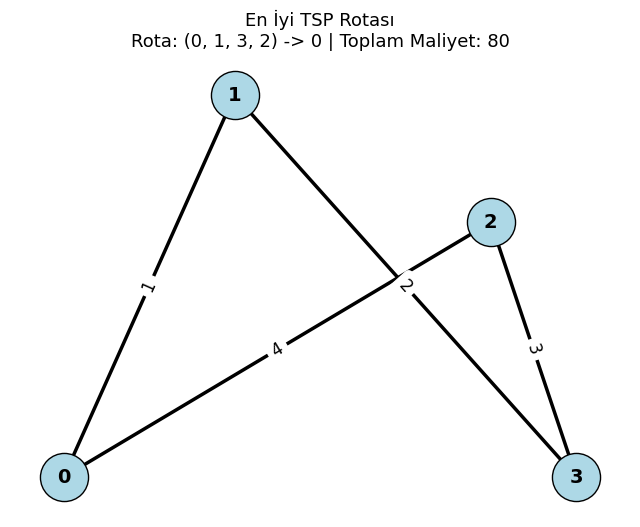

In [6]:
import matplotlib.pyplot as plt
import networkx as nx

# Şehir koordinatları
city_positions = {
    0: (0, 0),
    1: (2, 3),
    2: (5, 2),
    3: (6, 0)
}

# En iyi rota (önceki hücreden de alınabilir)
best_route = results_df.iloc[0]["Rota"]
best_cost = results_df.iloc[0]["Toplam Maliyet"]

# Turu kapatmak için başlangıç şehrini sona ekliyoruz
tour = list(best_route) + [best_route[0]]

# Grafik oluştur
G = nx.Graph()
G.add_nodes_from(cities)

# Turdaki kenarları ekle
tour_edges = [(tour[i], tour[i+1]) for i in range(len(tour)-1)]
G.add_edges_from(tour_edges)

plt.figure(figsize=(8, 6))

# Şehir düğümleri
nx.draw_networkx_nodes(
    G,
    city_positions,
    node_size=1200,
    node_color="lightblue",
    edgecolors="black"
)

# Şehir etiketleri
nx.draw_networkx_labels(
    G,
    city_positions,
    font_size=14,
    font_weight="bold"
)

# Tur kenarları
nx.draw_networkx_edges(
    G,
    city_positions,
    edgelist=tour_edges,
    width=2.5
)

# Kenar sırasını göstermek için etiketler
edge_labels = {}
for i in range(len(tour_edges)):
    edge_labels[tour_edges[i]] = f"{i+1}"

nx.draw_networkx_edge_labels(
    G,
    city_positions,
    edge_labels=edge_labels,
    font_size=12
)

plt.title(f"En İyi TSP Rotası\nRota: {best_route} -> {best_route[0]} | Toplam Maliyet: {best_cost}", fontsize=13)
plt.axis("off")
plt.show()

## Görselin Yorumlanması

Grafikte her düğüm bir şehri temsil etmektedir.  
Çizilen kenarlar ise brute-force yöntemi ile bulunan en iyi turun izlediği yolu göstermektedir.

Kenarların üzerindeki numaralar, ziyaret sırasını belirtmektedir.

Bu görselleştirme ile:

- turun hangi şehirden başladığı,
- hangi sırayla ilerlediği,
- ve nasıl başlangıç noktasına geri döndüğü

açıkça görülebilir.

Bu adım, problemi yalnızca sayısal olarak değil, yapısal olarak da anlamaya yardımcı olur.  
Bir sonraki aşamada, bu çözüm uzayının neden hızla büyüdüğünü ve neden daha gelişmiş yöntemlere ihtiyaç duyulduğunu inceleyebiliriz.

# Arama Uzayının Büyümesi ve Klasik Yöntemlerin Sınırları

## Arama Uzayı Nedir?

Gezgin Satıcı Problemi (TSP) bir optimizasyon problemi olmasına rağmen, aynı zamanda bir **arama problemi** olarak da düşünülebilir.

Bu durumda:

- Her olası rota bir **aday çözüm**dür
- Tüm rotalar birlikte **arama uzayını** oluşturur

---

## Arama Uzayının Büyüklüğü

Bir TSP probleminde, \( n \) şehir için olası tur sayısı:

$$
(n - 1)!
$$

şeklindedir.

Başlangıç şehri sabitlendiğinde bile bu sayı çok hızlı büyür.

Örnekler:

- 4 şehir → 3! = 6 rota  
- 5 şehir → 4! = 24 rota  
- 6 şehir → 5! = 120 rota  
- 10 şehir → 9! ≈ 362,880 rota  
- 15 şehir → 14! ≈ 87 milyar rota  

---

## Brute-Force Yaklaşımın Sınırı

Brute-force yöntemi:

1. tüm olası rotaları üretir  
2. her birinin maliyetini hesaplar  
3. en küçük olanı seçer  

Bu yaklaşım küçük problemler için çalışır, ancak:

- rota sayısı **faktöriyel olarak büyür**
- hesaplama süresi çok hızlı artar
- büyük problemler için pratik olmaktan çıkar

Bu nedenle brute-force yöntemi:

- teorik olarak doğru
- fakat pratikte sınırlıdır

---

## TSP'yi Arama Problemi Olarak Düşünmek

Bu noktada problemi farklı bir bakış açısıyla ele alabiliriz:

- "En kısa rotayı bul" yerine  
- "Belirli bir koşulu sağlayan rotayı bul"  

Örneğin:

- maliyeti belirli bir eşikten küçük olan rotalar
- veya geçerli (valid) turlar

Bu bakış açısı problemi bir **arama problemi** haline getirir.

---

## Neden Bu Önemli?

Bu dönüşüm sayesinde:

- optimizasyon problemi → arama problemi haline gelir
- tüm çözüm uzayı açıkça tanımlanır
- aday çözümler tek tek değerlendirilebilir

Bu yapı, klasik algoritmaların yanında **kuantum arama algoritmaları** için de uygundur.

---

## Kuantum Yaklaşıma Geçiş

Klasik yöntemlerde tüm aday çözümler tek tek kontrol edilirken, kuantum hesaplama farklı bir yaklaşım sunar:

- tüm olası durumlar aynı anda temsil edilebilir (süperpozisyon)
- belirli koşulu sağlayan durumlar işaretlenebilir (oracle)
- bu durumların bulunma olasılığı artırılabilir

Bu noktada devreye giren temel algoritma:

## **Grover Search Algoritması**

Grover algoritması:

- yapılandırılmamış arama problemlerinde
- klasik yöntemlere göre daha az adımda
- istenen çözümü bulmayı amaçlar

---

## Notebook İçin Sonraki Adım

Bir sonraki bölümde:

- TSP çözüm uzayını nasıl **bit string** olarak temsil edeceğimizi,
- geçerli rotaları nasıl tanımlayacağımızı,
- ve Grover algoritması için gerekli **oracle yapısını**

adım adım inceleyeceğiz.

# TSP Çözümlerinin Bit String ile Temsili

## Neden Kodlama (Encoding) Gerekli?

Grover algoritması, problemleri doğrudan şehirler ve rotalar üzerinden değil,  
**bit string (ikili diziler)** üzerinden işler.

Bu nedenle TSP çözüm uzayını:

- şehir sıralamalarından
- → bit dizilerine

dönüştürmemiz gerekir.

---

## Temel Fikir

Bir TSP çözümü aslında bir **permütasyondur**:

Örnek:

(0, 1, 3, 2)

Bu rota şu anlama gelir:

- 0 → 1 → 3 → 2 → 0

Ancak kuantum bilgisayarlar bu yapıyı doğrudan kullanamaz.  
Bu yüzden her çözümü bir bit dizisi ile temsil ederiz.

---

## Basit Kodlama Yaklaşımı

En basit yöntem:

- Tüm olası rotaları listelemek
- Her rotaya bir indeks vermek
- Bu indeksi binary (ikili) olarak yazmak

---

## Örnek: 4 Şehir

4 şehir için (başlangıç sabit):

Toplam rota sayısı:

$$
(4 - 1)! = 6
$$

Bu 6 rota şöyle olabilir:

| İndeks | Rota            |
|--------|-----------------|
| 0      | (0, 1, 2, 3)    |
| 1      | (0, 1, 3, 2)    |
| 2      | (0, 2, 1, 3)    |
| 3      | (0, 2, 3, 1)    |
| 4      | (0, 3, 1, 2)    |
| 5      | (0, 3, 2, 1)    |

---

## Binary (Bit String) Gösterim

6 farklı durum olduğu için en az:

$$
\lceil \log_2(6) \rceil = 3
$$

bit gerekir.

Bu durumda:

| Rota            | Bit string |
|-----------------|-----------|
| (0,1,2,3)       | 000       |
| (0,1,3,2)       | 001       |
| (0,2,1,3)       | 010       |
| (0,2,3,1)       | 011       |
| (0,3,1,2)       | 100       |
| (0,3,2,1)       | 101       |

---

## Dikkat Edilmesi Gereken Nokta

3 bit ile toplam:

$$
2^3 = 8
$$

durum temsil edilebilir.

Ancak sadece 6 tanesi geçerli rotadır.

Yani:

- 000 → geçerli
- 001 → geçerli
- ...
- 101 → geçerli
- 110 → geçersiz
- 111 → geçersiz

---

## Bu Ne Anlama Gelir?

Grover algoritması açısından:

- tüm 8 durum süperpozisyonda bulunur
- sadece **geçerli rotalar** dikkate alınmalıdır
- geçersiz durumlar oracle tarafından elenmelidir

---

## Oracle Mantığı

Grover algoritmasında bir **oracle fonksiyonu**:

- geçerli ve istenen çözümleri işaretler

TSP için bu şu anlama gelir:

Bir bit string:

1. Geçerli bir rota mı?
2. İstenen maliyet koşulunu sağlıyor mu?

Eğer sağlıyorsa → işaretlenir (phase flip)

---

## Özet

Bu bölümde:

- TSP çözüm uzayını bit string olarak ifade ettik
- geçerli ve geçersiz durumları ayırdık
- Grover algoritması için gerekli temsil biçimini oluşturduk

---

## Sonraki Adım

Bir sonraki bölümde:

- bu bit string yapısı üzerinde çalışan bir **oracle fonksiyonu**
- yani "iyi rotaları işaretleyen" mekanizmayı

tasarlayacağız.

# Bit-String Uzayının Oluşturulması ve İlk Oracle Yapısı

Bu bölümde Grover algoritmasının temel bileşenlerini küçük bir örnek üzerinden oluşturacağız.

Amacımız:

1. TSP çözüm uzayını temsil eden bit-string durumlarını kuantum devresinde hazırlamak,
2. Hadamard kapıları ile tüm olası durumları süperpozisyona almak,
3. Belirli bir hedef durumu işaretleyen basit bir oracle tanımlamak.

---

## Süperpozisyon Fikri

Klasik bir sistemde aday çözümler tek tek değerlendirilirken, kuantum hesaplamada tüm olası bit-string durumları aynı anda temsil edilebilir.

Örneğin 3 qubit kullanırsak, aşağıdaki 8 durum aynı anda temsil edilir:

- 000
- 001
- 010
- 011
- 100
- 101
- 110
- 111

Hadamard kapıları bu durumların eşit olasılıkla süperpozisyona alınmasını sağlar.

---

## Oracle Nedir?

Grover algoritmasında oracle, istenen çözümü işaretleyen bir bileşendir.

Bu işaretleme doğrudan ölçüm sonucu üretmez.  
Bunun yerine hedef durumun fazını değiştirir.

Yani oracle:

- iyi çözümleri tanır
- bu çözümlere faz çevirimi uygular
- sonraki adımda diffusion operatörü ile bu durumların ölçülme olasılığı artırılır

---

## Neden Belirli Bir Bit-String Seçiyoruz?

Bu aşamada henüz gerçek TSP maliyet hesaplamasını kuantum devreye dahil etmedik.

Bu nedenle:

- hangi bit-string’in "iyi çözüm" olduğunu belirleyen gerçek bir kriterimiz yoktur.

Bu yüzden, Grover algoritmasının çalışma prensibini göstermek amacıyla:

-> **örnek olarak tek bir bit-string'i “iyi çözüm” kabul ediyoruz**

---

## Örnek Seçim: 101

Bu örnekte:

- **101** bit-string'i hedef durum olarak seçilecektir.

Bu seçim:

- tamamen **didaktik (öğretici) amaçlıdır**
- rastgele seçilmiştir
- gerçek TSP çözümünü temsil etmek zorunda değildir

---

## TSP ile Bağlantı

Daha sonraki adımlarda bu yaklaşımı şu şekilde genişleteceğiz:

- Her bit-string → bir rota indeksini temsil edecek
- Oracle → sadece "iyi rotaları" işaretleyecek
- "İyi rota" → düşük maliyetli tur anlamına gelecek

Yani şu an:

-> `101` = "örnek iyi çözüm"

ileride ise:

-> `101` = "gerçekten iyi bir TSP rotası"

haline gelecektir.

---

## Bu Bölümdeki Basitleştirme

Bu ilk örnekte oracle, yalnızca tek bir hedef bit-string'i işaretleyecektir.

Bu yaklaşım, daha sonra TSP için:

- geçerli rota kontrolü
- maliyet eşiği kontrolü
- iyi çözümlerin işaretlenmesi

gibi daha gelişmiş oracle yapılarının temelini oluşturacaktır.

# 1. Qubit Sayısının Belirlenmesi

Bu örnekte 4 şehir için başlangıç şehri sabit tutulduğunda toplam **6 farklı rota** elde edilir.

Bu rotaları Grover algoritmasında bit-string olarak temsil edebilmek için yeterli sayıda qubit kullanmamız gerekir.

3 qubit ile toplam:

$$
2^3 = 8
$$

farklı durum temsil edilebilir.

Bu nedenle 6 rotayı kodlamak için **3 qubit** yeterlidir.

Bu bölümde önce 3 qubit’lik boş bir kuantum devresi oluşturacağız.

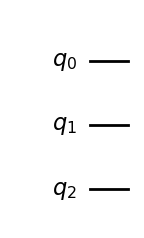

In [12]:
from qiskit import QuantumCircuit

# 4 şehir için sabit başlangıçlı 6 farklı rota vardı.
# Bu rotaları temsil etmek için 3 qubit yeterlidir çünkü 2^3 = 8 durum üretir.

n_qubits = 3

# 3 qubit'lik boş kuantum devresi oluşturuyoruz
qc = QuantumCircuit(n_qubits)

# Devreyi çizdiriyoruz
qc.draw("mpl")

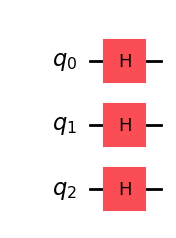

Durum vektörü:


<IPython.core.display.Latex object>

In [8]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# 3 qubit -> 2^3 = 8 durum
n_qubits = 3

qc_superposition = QuantumCircuit(n_qubits)

# Tüm qubit'lere Hadamard uygulayarak eşit süperpozisyon oluşturuyoruz
qc_superposition.h(range(n_qubits))

# Devreyi çiz
display(qc_superposition.draw("mpl"))

# Durum vektörünü incele
sv = Statevector.from_instruction(qc_superposition)
print("Durum vektörü:")
display(sv.draw("latex"))

Bu aşamada henüz herhangi bir kapı uygulanmamıştır.  
Yalnızca çözüm uzayını temsil edecek temel kuantum devresi oluşturulmuştur.

Bir sonraki adımda, Hadamard kapıları kullanılarak tüm olası bit-string durumları süperpozisyona alınacaktır.

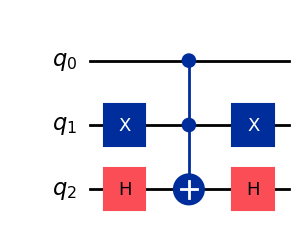

In [14]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

def phase_oracle_for_101():
    """
    |101> durumunun fazını çeviren basit oracle.
    """
    oracle = QuantumCircuit(3, name="Oracle")

    # Hedef durum: 101
    # ccZ uygulamak için önce 0 olan biti 1'e çeviriyoruz.
    # Bit dizisi: q2 q1 q0 = 1 0 1
    # Ortadaki bit 0 olduğu için q1 üzerine X uygula.
    oracle.x(1)

    # CCZ'yi H-CX-H ile gerçekleştiriyoruz
    oracle.h(2)
    oracle.ccx(0, 1, 2)
    oracle.h(2)

    # Geri al
    oracle.x(1)

    return oracle

oracle = phase_oracle_for_101()

display(oracle.draw("mpl"))

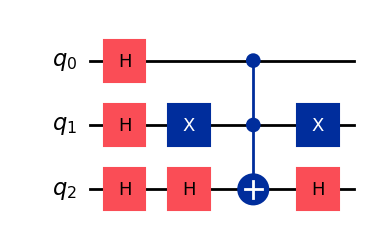

Oracle uygulandıktan sonraki durum vektörü:


<IPython.core.display.Latex object>

In [15]:
qc_oracle_demo = QuantumCircuit(3)

# 1. Süperpozisyon
qc_oracle_demo.h([0, 1, 2])

# 2. Oracle
qc_oracle_demo.compose(oracle, inplace=True)

display(qc_oracle_demo.draw("mpl"))

# Oracle sonrası durum vektörü
sv_after_oracle = Statevector.from_instruction(qc_oracle_demo)

print("Oracle uygulandıktan sonraki durum vektörü:")
display(sv_after_oracle.draw("latex"))

## Oracle Sonrası Yorum

Oracle uygulandıktan sonra tüm durumların olasılıkları hemen değişmez.  
Ancak hedef durumun fazı ters çevrilmiş olur.

Bu noktada henüz ölçüm yapıldığında hedef durumun doğrudan baskın hale gelmesi beklenmez.

Grover algoritmasının asıl gücü:

1. oracle ile iyi durumları işaretlemek,
2. diffusion operatörü ile bu durumların genliklerini büyütmek

adımlarının birlikte uygulanmasından gelir.

Bu nedenle burada oluşturulan oracle, Grover algoritmasının yalnızca ilk temel bileşenidir.

# Grover Diffusion Operator ve Tek Grover İterasyonu

Grover algoritması iki temel bileşenden oluşur:

1. **Oracle**
2. **Diffusion operator**

Oracle, hedef durumu işaretler.  
Diffusion operator ise işaretlenen durumun genliğini büyütmeye yardımcı olur.

Bu işlem sayesinde hedef çözümün ölçülme olasılığı artırılır.

---

## Diffusion Operator Nedir?

Diffusion operator, bazen **inversion about the mean** olarak da adlandırılır.

Temel fikir şudur:

- Oracle hedef durumun fazını ters çevirir
- Diffusion operator ise tüm genlikleri ortalamaya göre yansıtır
- Böylece işaretlenen durumların genliği büyür

Grover algoritmasının hız kazandıran kısmı bu adımdır.

---

## Matematiksel Fikir

Diffusion operator şu dönüşümü temsil eder:

$$
D = 2|s\rangle \langle s| - I
$$

Burada:

- \( |s\rangle \): eşit süperpozisyon durumu
- \( I \): birim operatör

Bu dönüşüm, genlikleri ortalama etrafında yansıtır.

---

## Bu Bölümde Ne Yapacağız?

Bu adımda:

1. 3 qubit için diffusion operator tanımlayacağız
2. Oracle ile birlikte tek bir Grover iterasyonu oluşturacağız
3. Sonucu ölçmeden önce durumun nasıl değiştiğini inceleyeceğiz

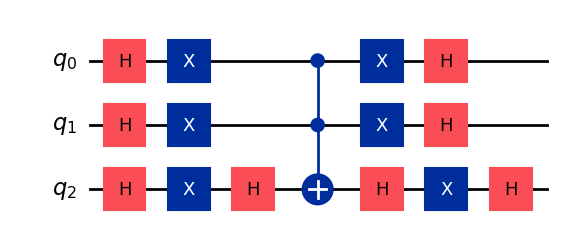

In [17]:
from qiskit import QuantumCircuit

def diffusion_operator(n_qubits):
    """
    n qubit için Grover diffusion operator oluşturur.
    """
    qc = QuantumCircuit(n_qubits, name="Diffusion")

    # 1. Tüm qubit'lere H uygula
    qc.h(range(n_qubits))
    
    # 2. Tüm qubit'lere X uygula
    qc.x(range(n_qubits))

    # 3. |000...0> durumuna faz çevirimi uygula
    # Bunun için çok kontrollü Z benzeri yapı kuruyoruz
    qc.h(n_qubits - 1)
    qc.mcx(list(range(n_qubits - 1)), n_qubits - 1)
    qc.h(n_qubits - 1)

    # 4. Geri al
    qc.x(range(n_qubits))
    qc.h(range(n_qubits))

    return qc

diffuser = diffusion_operator(3)
diffuser.draw("mpl")

## Diffusion Operator Adımlarının Yorumu

Diffusion operator oluşturulurken şu sıra izlenir:

1. Hadamard kapıları ile hesaplama bazı tekrar süperpozisyon bazına taşınır
2. X kapıları ile hedef durum \( |000\rangle \) etrafında işlem yapılacak hale getirilir
3. Çok kontrollü faz çevirimi uygulanır
4. X ve H kapıları geri alınır

Bu yapı, işaretlenmiş durumların genliklerini artıracak dönüşümü gerçekleştirir.

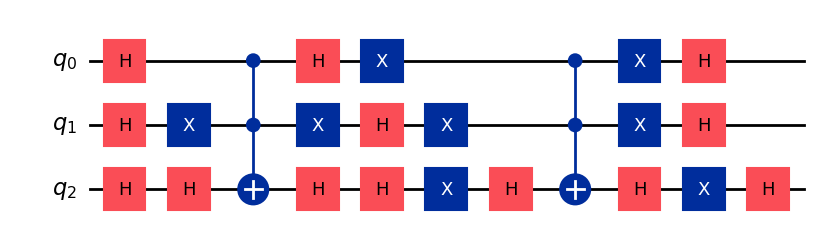

In [18]:
from qiskit.quantum_info import Statevector

# Oracle fonksiyonu (önceki adımdaki sade hali)
def phase_oracle_for_101():
    oracle = QuantumCircuit(3, name="Oracle")

    # Hedef: |101>
    # q1 biti 0 olduğu için önce X ile tersliyoruz
    oracle.x(1)

    # CCZ eşleniği
    oracle.h(2)
    oracle.ccx(0, 1, 2)
    oracle.h(2)

    # Geri al
    oracle.x(1)

    return oracle

oracle = phase_oracle_for_101()
diffuser = diffusion_operator(3)

# Tek Grover iterasyonu
grover_qc = QuantumCircuit(3)

# 1. Eşit süperpozisyon
grover_qc.h([0, 1, 2])

# 2. Oracle
grover_qc.compose(oracle, inplace=True)

# 3. Diffusion
grover_qc.compose(diffuser, inplace=True)

grover_qc.draw("mpl")

In [19]:
sv_grover = Statevector.from_instruction(grover_qc)

print("Tek Grover iterasyonu sonrası durum vektörü:")
display(sv_grover.draw("latex"))

Tek Grover iterasyonu sonrası durum vektörü:


<IPython.core.display.Latex object>

In [20]:
import pandas as pd
import numpy as np

probabilities = sv_grover.probabilities_dict()

df_probs = pd.DataFrame({
    "Durum": list(probabilities.keys()),
    "Olasılık": list(probabilities.values())
})

df_probs = df_probs.sort_values(by="Durum").reset_index(drop=True)
df_probs

,Durum,Olasılık
0,000,0.03125
1,001,0.03125
2,010,0.03125
3,011,0.03125
4,100,0.03125
5,101,0.78125
6,110,0.03125
7,111,0.03125


## Tek Grover İterasyonunun Yorumu

Bu devrede şu adımlar uygulanmıştır:

1. Tüm durumlar eşit süperpozisyona alınmıştır  
2. Oracle, hedef durumun fazını ters çevirmiştir  
3. Diffusion operator, hedef durumun genliğini büyütmüştür  

---

## Faz ve Olasılık İlişkisi

Önemli bir nokta şudur:

- Oracle, hedef durumun **olasılığını doğrudan değiştirmez**
- Sadece o durumun **fazını (işaretini)** değiştirir

Yani oracle sonrası:

- tüm durumların büyüklüğü aynıdır
- sadece hedef durum negatif işaret alır

Bu noktada henüz ölçüm sonucu değişmez.

---

## Diffusion Operator'ın Rolü

Diffusion operator, bu faz farkını kullanarak:

- genlikleri ortalama etrafında yansıtır
- negatif fazlı durumu "öne çıkarır"
- böylece hedef durumun genliği büyür

Sonuç olarak:

->  faz farkı → genlik farkına dönüşür  
->  genlik farkı → ölçüm olasılığına yansır  

---

## Sonuç

Bu işlem sonucunda hedef bit-string'in ölçülme olasılığı diğer durumlara göre artar.

Henüz yalnızca **tek iterasyon** uygulanmıştır.  
Grover algoritmasında hedef durum sayısına ve toplam durum sayısına bağlı olarak uygun sayıda iterasyon seçilerek başarı olasılığı daha da yükseltilebilir.

---

## Önemli Not

Grover algoritmasının gücü:

- oracle'ın tek başına yaptığı işten değil,
- oracle ve diffusion operator'un **birlikte tekrar edilmesinden** gelir.